# Adding Features to California Housing Dataset

Mean Squared Error: 0.5502090739420752
R² Score: 0.580124157359881
             Feature  Coefficient
0             MedInc     0.427137
1           HouseAge     0.003103
2           AveRooms    -0.111536
3          AveBedrms     0.780540
4         Population    -0.000034
5           AveOccup    -0.003656
6           Latitude    -0.423817
7          Longitude    -0.437065
8       Income_Rooms    -0.004427
9    Income_HouseAge     0.001677
10  Rooms_Population     0.000006


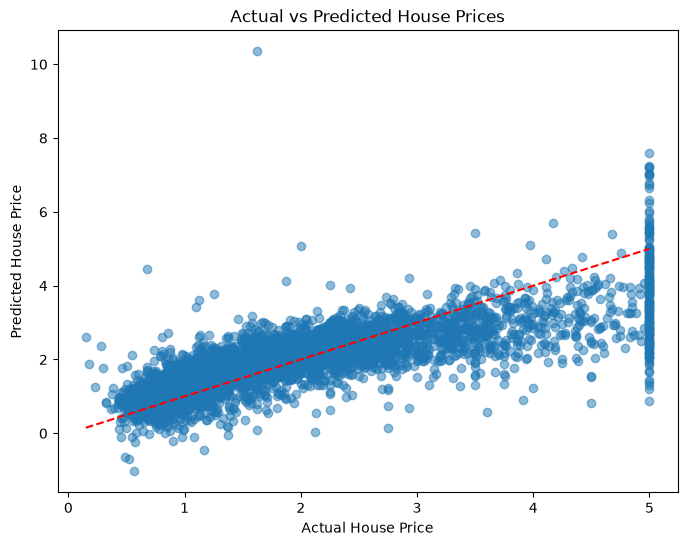

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

california = fetch_california_housing(as_frame=True)
df = california.frame

df['Income_Rooms'] = df['MedInc'] * df['AveRooms']
df['Income_HouseAge'] = df['MedInc'] * df['HouseAge']
df['Rooms_Population'] = df['AveRooms'] * df['Population']

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})

print(coefficients)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()